In [66]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def analyze_lnn_memory_impact(
    n_neuron=256,
    input_dim=19,                  
    
    # --- 1. Baseline: FP32 (Software / GPU Standard) ---
    fp32_bits=32,                   
    
    # --- 2. Competitor: INT8 (Standard Edge NPU) ---
    int8_bits=8,                   
    # CAM/LUTの設定
    prop_cam_in_bits=8,            
    prop_lut_out_bits=8,          
    prop_processor_sram_bits=8,          
    prop_processor_rram_bits=8,            
    prop_weight_bits=8,
    block=None,
    bit_range=[1,2,3,4,5,6,7,8],                          
):
    """
    FP32, INT8, 提案手法の3つのメモリ容量を比較するシミュレーション
    各量子化パラメータはリストでも単一値でも可
    """
    if block is not None:
        if block=="CAM":
            prop_cam_in_bits = bit_range
        elif block=="LUT":
            prop_lut_out_bits = bit_range
        elif block=="SRAM":
            prop_processor_sram_bits = bit_range
        elif block=="RRAM":
            prop_processor_rram_bits = bit_range
        elif block=="Weight":
            prop_weight_bits = bit_range    
        else:
            raise ValueError("Invalid block name for sweeping bits.")
    
    results = []
    
    # 各パラメータがリストかどうか判定し、リスト化
    def ensure_list(x):
        return x if isinstance(x, (list, tuple, np.ndarray)) else [x]

    cam_bits_list = ensure_list(prop_cam_in_bits)
    lut_bits_list = ensure_list(prop_lut_out_bits)
    proc_sram_bits_list = ensure_list(prop_processor_sram_bits)
    proc_rram_bits_list = ensure_list(prop_processor_rram_bits)
    weight_bits_list = ensure_list(prop_weight_bits)

    for cam_bits in cam_bits_list:
        for lut_bits in lut_bits_list:
            for proc_sram_bits in proc_sram_bits_list:
                for proc_rram_bits in proc_rram_bits_list:
                    for weight_bits in weight_bits_list:
                        # 共通パラメータ: 重みの総数
                        total_params_weight = (n_neuron + input_dim) * n_neuron
                        
                        # 1. Baseline: FP32 (Full Precision)
                        size_fp32_mvm = total_params_weight * fp32_bits
                        total_fp32_kbits = size_fp32_mvm / 1000
                        
                        # 2. Competitor: INT8 (Standard Quantization)
                        size_int8_mvm = total_params_weight * int8_bits * 2
                        size_int8_cam = (2**int8_bits) * int8_bits # CAM overhead
                        size_int8_lut = n_neuron * (2**int8_bits) * int8_bits # LUT overhead
                        size_int8_processor = 4 * n_neuron * int8_bits # その他プロセッサオーバーヘッド
                        total_int8_kbits = (size_int8_mvm + size_int8_cam + size_int8_lut + size_int8_processor) / 1000
                        
                        # 3. Proposed (Mixed Precision & Architecture)
                        size_prop_mvm = total_params_weight * weight_bits * 2
                        entries = 2 ** cam_bits
                        size_prop_cam = entries * cam_bits # Key
                        size_prop_lut = n_neuron * entries * lut_bits # Value
                        size_prop_processor = n_neuron * (3 * proc_rram_bits + proc_sram_bits) # その他プロセッサオーバーヘッド
                        total_prop_kbits = (size_prop_mvm + size_prop_cam + size_prop_lut + size_prop_processor) / 1000
                        
                        # 削減率の計算 (vs FP32)
                        reduction_vs_fp32 = (total_prop_kbits / total_fp32_kbits) * 100
                        reduction_vs_int8 = (total_prop_kbits / total_int8_kbits) * 100
                        
                        results.append({
                            "Neuron Count": n_neuron,
                            "CAM Size": size_prop_cam,
                            "LUT Size": size_prop_lut,
                            "Processor Size": size_prop_processor,
                            "MVM Size": size_prop_mvm,
                            "FP32 Size (kbits)": total_fp32_kbits,
                            "INT8 Size (kbits)": total_int8_kbits,
                            "Ours Size (kbits)": total_prop_kbits,
                            "Red. vs FP32 (%)": reduction_vs_fp32,
                            "Red. vs INT8 (%)": reduction_vs_int8
                        })
    return pd.DataFrame(results)

In [78]:
def plot_quantization_results(block, bit_range):
    import numpy as np
    import matplotlib.pyplot as plt
    import matplotlib.ticker as ticker
    import seaborn as sns
    import glob
    import re
    import pandas as pd

    units = [64, 128, 256]
    base_path = "/work/robomimic/csv/result/quantize/"+ block
    TOP_K = 10  # 上位k行で平均

    def extract_bit(path):
        m = re.search(r"([0-9.]+)bit.csv", path)
        return float(m.group(1)) if m else None

    results = []

    for unit in units:
        pattern = f"{base_path}/unit{unit}/*.csv"
        files = sorted(glob.glob(pattern))

        for f in files:
            bit = extract_bit(f)
            if bit is None:
                continue

            df = pd.read_csv(f)

            # 行そのものから success_rate 上位kを選択
            topk = df.nlargest(TOP_K, "success_rate")
            mean_success = topk["success_rate"].mean()
            std_success = topk["success_rate"].std()

            results.append({
                "unit": unit,
                "bit": bit,
                "mean_success": mean_success,
                "std_success": std_success
            })

    results_df = pd.DataFrame(results)
    print(results_df)

    sns.set_style("white")

    custom_colors = {
        "u64": "#351fb4",
        "u128": "#06a600",
        "u256": "#d62728",
    }
    markers = {
        "u64": "s",
        "u128": "o",
        "u256": "^",
    }

    # ===== フォントサイズ =====
    TICK_SIZE = 25
    LABEL_SIZE = 28
    LEGEND_SIZE = 22

    # ===== メモリ計算 =====
    bit_range = np.arange(2, 9, 1)

    df_mem = analyze_lnn_memory_impact(
        block=block,
        bit_range=bit_range
    )

    # ===== Figure & Axes =====
    fig, ax1 = plt.subplots(figsize=(8, 5))
    ax2 = ax1.twinx()

    # ===== 左軸：Success Rate =====
    for unit in units:
        df_u = results_df[results_df["unit"] == unit].sort_values("bit")
        df_u = df_u[df_u["bit"] != 1]

        ax1.plot(
            df_u["bit"],
            df_u["mean_success"] * 100,
            color=custom_colors[f"u{unit}"],
            linewidth=3,
            zorder=4,
        )

        ax1.scatter(
            df_u["bit"],
            df_u["mean_success"] * 100,
            marker=markers[f"u{unit}"],
            s=180,
            facecolors="white",
            edgecolors=custom_colors[f"u{unit}"],
            linewidths=3,
            zorder=5,
        )

        ax1.errorbar(
            df_u["bit"],
            df_u["mean_success"] * 100,
            yerr=df_u["std_success"] * 100,
            fmt="none",
            ecolor=custom_colors[f"u{unit}"],
            elinewidth=2.5,
            capsize=6,
            zorder=3,
            alpha=1.0,
        )

    # ===== 右軸：Memory (kbits) =====
    ax2.bar(
        bit_range,
        df_mem["Red. vs INT8 (%)"],
        width=0.8,
        color="#9A9898",
        alpha=1.0,
        zorder=2,
    )

    # ===== 軸レンジ =====
    ax1.set_xlim(1.5, 8.5)
    ax1.set_ylim(0, 105)
    ax2.set_ylim(0, 105)

    # ===== Tick 設定 =====
    ax1.set_xticks(bit_range)
    ax1.set_yticks(np.arange(0, 101, 20))

    ax1.tick_params(axis="x", labelsize=TICK_SIZE, width=2.5)
    ax1.tick_params(axis="y", labelsize=TICK_SIZE, width=2.5)
    ax2.tick_params(axis="y", labelsize=TICK_SIZE, width=2.5)

    for tick in ax1.get_xticklabels() + ax1.get_yticklabels() + ax2.get_yticklabels():
        tick.set_fontweight("bold")

    # ===== 基準線 =====
    ax1.yaxis.grid(False)
    ax1.xaxis.grid(False)

    ax2.set_axisbelow(True) 
    ax2.yaxis.grid(True, which='major', linestyle='--', linewidth=1.0, zorder=0)

    ax2.set_yticks(np.arange(0, 101, 20))

    ax2.axhline(95, linestyle="--", color="black", linewidth=3, zorder=3)
    ax1.set_zorder(ax2.get_zorder() + 1)  
    ax1.patch.set_visible(False)


    # ===== 枠線 =====
    for spine in ax1.spines.values():
        spine.set_linewidth(2.5)
    for spine in ax2.spines.values():
        spine.set_linewidth(2.5)

    plt.tight_layout()
    plt.show()

    unit  bit  mean_success  std_success
0     64  1.0       0.00000     0.000000
1     64  2.0       0.07700     0.155210
2     64  3.0       0.86400     0.044771
3     64  4.0       0.95100     0.024244
4     64  5.0       0.97800     0.014757
5     64  6.0       0.98300     0.014944
6     64  7.0       0.97400     0.017127
7     64  8.0       0.96375     0.024458
8    128  1.0       0.00000     0.000000
9    128  2.0       0.07200     0.169102
10   128  3.0       0.78300     0.123293
11   128  4.0       0.97300     0.012517
12   128  5.0       0.98900     0.011005
13   128  6.0       0.98900     0.008756
14   128  7.0       0.99100     0.005676
15   256  1.0       0.00400     0.006992
16   256  2.0       0.07800     0.046140
17   256  3.0       0.64300     0.113044
18   256  4.0       0.97300     0.023118
19   256  5.0       0.98000     0.014142
20   256  6.0       0.98900     0.009944
21   256  7.0       0.98700     0.011595


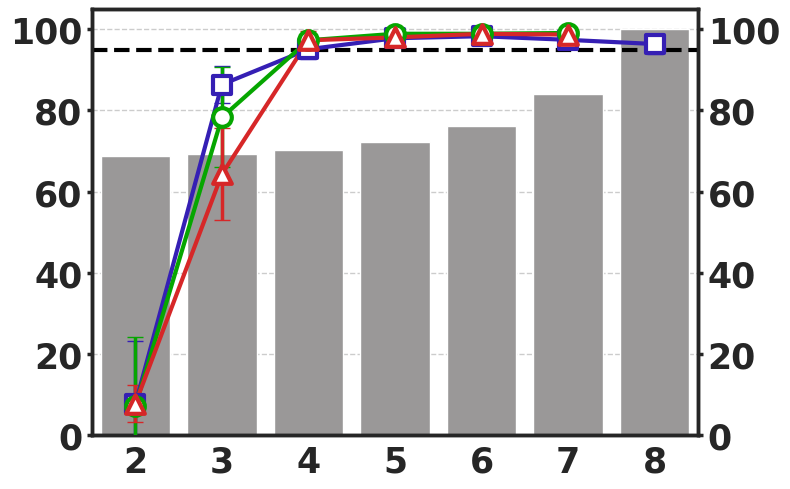

    unit  bit  mean_success  std_success
0     64  1.0         0.404     0.061319
1     64  2.0         0.920     0.040552
2     64  3.0         0.969     0.011972
3     64  4.0         0.986     0.008433
4     64  5.0         0.982     0.009189
5     64  6.0         0.983     0.006749
6     64  7.0         0.984     0.009661
7     64  8.0         0.986     0.006992
8    128  1.0         0.430     0.086667
9    128  2.0         0.923     0.029458
10   128  3.0         0.980     0.004714
11   128  4.0         0.989     0.007379
12   128  5.0         0.994     0.005164
13   128  6.0         0.991     0.003162
14   128  7.0         0.994     0.006992
15   128  8.0         0.995     0.005270
16   256  1.0         0.460     0.137760
17   256  2.0         0.911     0.040125
18   256  3.0         0.975     0.012693
19   256  4.0         0.988     0.010328
20   256  5.0         0.991     0.007379
21   256  6.0         0.990     0.010541
22   256  7.0         0.992     0.006325
23   256  8.0   

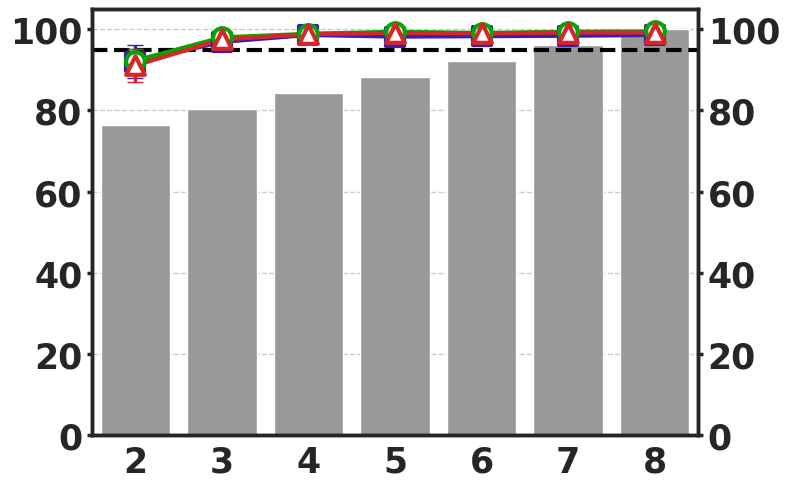

    unit  bit  mean_success  std_success
0     64  2.0         0.013     0.019465
1     64  3.0         0.217     0.301000
2     64  4.0         0.879     0.060818
3     64  5.0         0.962     0.026998
4     64  6.0         0.982     0.012293
5     64  7.0         0.984     0.006992
6     64  8.0         0.982     0.009189
7    128  2.0         0.027     0.068484
8    128  3.0         0.727     0.172630
9    128  4.0         0.922     0.036454
10   128  5.0         0.982     0.009189
11   128  6.0         0.990     0.008165
12   128  7.0         0.990     0.008165
13   128  8.0         0.992     0.006325
14   256  2.0         0.070     0.115950
15   256  3.0         0.822     0.080111
16   256  4.0         0.979     0.016633
17   256  5.0         0.987     0.010593
18   256  6.0         0.988     0.007888
19   256  7.0         0.993     0.008233
20   256  8.0         0.991     0.008756


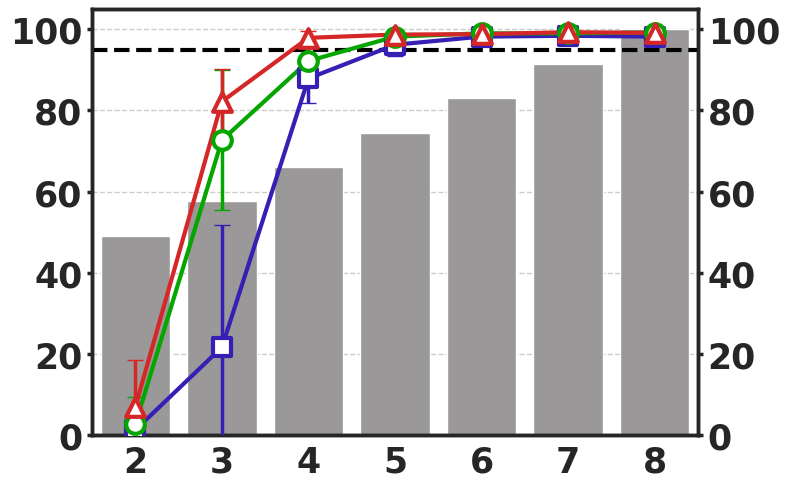

    unit  bit  mean_success  std_success
0     64  2.0         0.469     0.322712
1     64  3.0         0.874     0.074117
2     64  4.0         0.962     0.022509
3     64  5.0         0.969     0.008756
4     64  6.0         0.979     0.012867
5     64  7.0         0.985     0.008498
6     64  8.0         0.986     0.008433
7    128  2.0         0.403     0.395195
8    128  3.0         0.891     0.038137
9    128  4.0         0.976     0.014298
10   128  5.0         0.985     0.008498
11   128  6.0         0.993     0.004830
12   128  7.0         0.993     0.004830
13   128  8.0         0.994     0.005164
14   256  2.0         0.644     0.314226
15   256  3.0         0.884     0.070111
16   256  4.0         0.969     0.021318
17   256  5.0         0.980     0.014142
18   256  6.0         0.986     0.011738
19   256  7.0         0.983     0.014181
20   256  8.0         0.988     0.007888


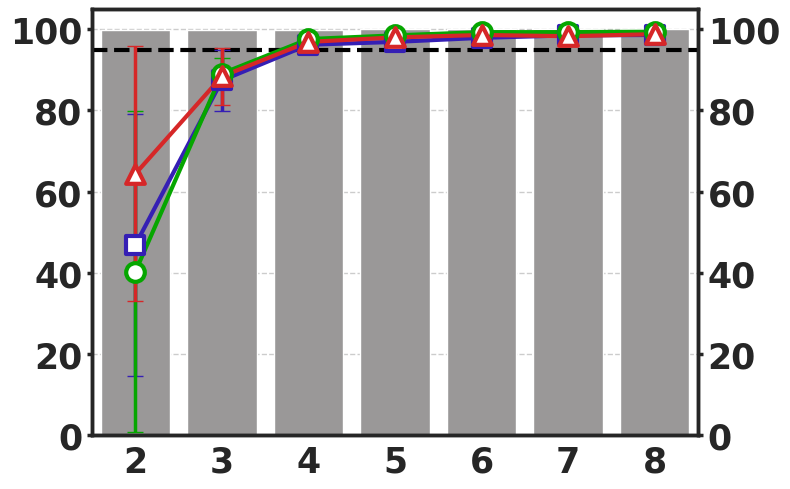

Empty DataFrame
Columns: []
Index: []


KeyError: 'unit'

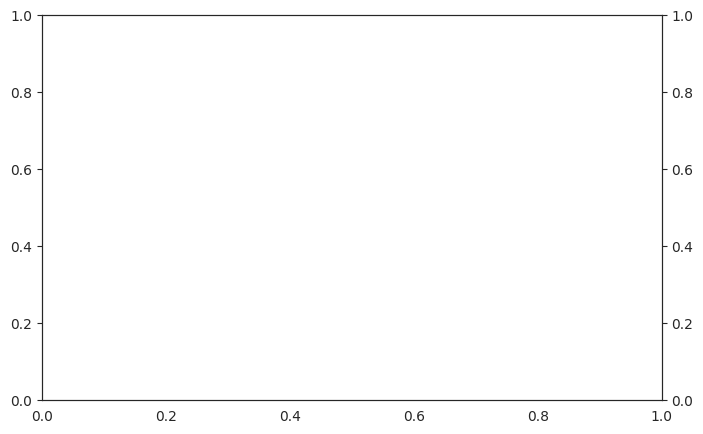

In [79]:
# CAM 
blocks=["CAM","LUT","Weight","SRAM","RRAM"]
for block in blocks:
    plot_quantization_results(block=block, bit_range=[2,3,4,5,6,7,8])